<a href="https://colab.research.google.com/github/abd-syah33/S3_Pengenalan-Pola/blob/Praktikum-3/Praktikum_3_Pengenalan_Pola.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : Syahid Abdullah

NIM : M0603251021

Link Github : https://github.com/abd-syah33/S3_Pengenalan-Pola/blob/Praktikum-3/Praktikum_3_Pengenalan_Pola.ipynb



# Pengambilan Keputusan Bayes pada Minimum Error Classiﬁcation

### Tugas 1. Lakukan Eksperimen terhadap data di atas dan catat luar dari setiap tahap yang dilakukan !

Praktikum ini berfokus pada pendekatan Minimum Error Classification, yaitu strategi keputusan
Bayes yang bertujuan meminimalkan probabilitas kesalahan dengan menggunakan Python.
Perhatikan beberapa  tahap berikut ini:  

1. Menyesuaikan dengan Library yang akan digunakan  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

2. Melakukan pembangkitan data untuk setiap kelas (Asumsi ada dua kelas)

In [2]:
# Dua class (Asumsi menggunakan Gaussian)
np.random.seed(42)

# Membangkitkan data kelas 1
mu1, sigma = 2, 0.8
x1 = np.random.normal(mu1, sigma, 100)

# Membangkitkan data kelas 2
mu2, sigma = 5, 1.0
x2 = np.random.normal(mu2, sigma, 100)

3. Menentukan Posterior Probability

In [3]:
# Posterior Probability
P_w1 = 0.4
P_w2 = 0.6

4. Membuat fungsi likelihood  

In [4]:
def likelihood(x, mu, sigma):
    return norm.pdf(x, mu, sigma)

5. Membuat fungsi posterior probability  

In [5]:
def posterior(x):
  p1 = likelihood(x, mu1, sigma) * P_w1
  p2 = likelihood(x, mu2, sigma) * P_w2
  return p1, p2

6. Membuat Fungsi Klasifikasi berdasarkan nilai posterior probability  

In [6]:
# Minimum error rule
def classify(x):
  p1, p2 = posterior(x)
  return np.where(p1 > p2, 1, 2)

7. Visualisasi Data bangkitan

[1.77273936e-03 1.91056673e-03 2.05781693e-03 2.21502415e-03
 2.38274408e-03 2.56155412e-03 2.75205353e-03 2.95486349e-03
 3.17062712e-03 3.40000943e-03 3.64369718e-03 3.90239868e-03
 4.17684345e-03 4.46778190e-03 4.77598479e-03 5.10224265e-03
 5.44736512e-03 5.81218015e-03 6.19753305e-03 6.60428551e-03
 7.03331441e-03 7.48551056e-03 7.96177732e-03 8.46302902e-03
 8.99018931e-03 9.54418936e-03 1.01259659e-02 1.07364592e-02
 1.13766108e-02 1.20473610e-02 1.27496468e-02 1.34843988e-02
 1.42525385e-02 1.50549758e-02 1.58926056e-02 1.67663047e-02
 1.76769285e-02 1.86253078e-02 1.96122453e-02 2.06385118e-02
 2.17048428e-02 2.28119344e-02 2.39604398e-02 2.51509656e-02
 2.63840671e-02 2.76602453e-02 2.89799421e-02 3.03435372e-02
 3.17513430e-02 3.32036019e-02 3.47004815e-02 3.62420710e-02
 3.78283777e-02 3.94593230e-02 4.11347390e-02 4.28543653e-02
 4.46178451e-02 4.64247228e-02 4.82744407e-02 5.01663364e-02
 5.20996403e-02 5.40734734e-02 5.60868454e-02 5.81386528e-02
 6.02276777e-02 6.235258

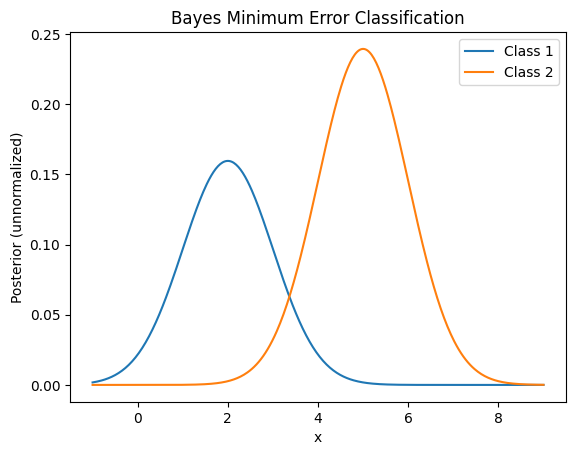

In [7]:
x_range = np.linspace(-1, 9, 400)

p1 = likelihood(x_range, mu1, sigma) * P_w1
p2 = likelihood(x_range, mu2, sigma) * P_w2

print(p1)
print(p2)

plt.figure()
plt.plot(x_range, p1, label='Class 1')
plt.plot(x_range, p2, label='Class 2')
plt.xlabel('x')
plt.ylabel('Posterior (unnormalized)')
plt.legend()
plt.title('Bayes Minimum Error Classification')
plt.show()

8. Melakukan klasifikasi dan menghitung error

In [8]:
from dataclasses import dataclass
# Gabungkan data
data = np.concatenate([x1, x2])
true_label = np.array([1]*len(x1) + [2]*len(x2))
print(true_label)

pred_label = classify(data)
print(pred_label)

error_rate = np.mean(pred_label != true_label)
print(f'Error rate: {error_rate}')

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 1
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
Error rate: 0.01


### Tugas 2. Lakukan perubahan pada nilai prior probability dan nilai mu dan sigma untuk masing - masing class dan catat errornya.

a. mu1=3, sigma1=0,8, mu2=4, sigma1=1, P_w1=0,2, P_w2=0,8

In [12]:
# Dua class (Asumsi menggunakan Gaussian)
np.random.seed(42)

# Membangkitkan data kelas 1
mu1, sigma = 3, 0.8
x1 = np.random.normal(mu1, sigma, 100)

# Membangkitkan data kelas 2
mu2, sigma = 4, 1.0
x2 = np.random.normal(mu2, sigma, 100)

# Posterior Probability
P_w1 = 0.2
P_w2 = 0.8

[2.67660452e-05 2.95791781e-05 3.26674475e-05 3.60554985e-05
 3.97699469e-05 4.38395131e-05 4.82951630e-05 5.31702563e-05
 5.85007017e-05 6.43251193e-05 7.06850109e-05 7.76249372e-05
 8.51927030e-05 9.34395499e-05 1.02420356e-04 1.12193844e-04
 1.22822796e-04 1.34374275e-04 1.46919855e-04 1.60535858e-04
 1.75303594e-04 1.91309611e-04 2.08645951e-04 2.27410408e-04
 2.47706794e-04 2.69645205e-04 2.93342298e-04 3.18921561e-04
 3.46513593e-04 3.76256381e-04 4.08295578e-04 4.42784778e-04
 4.79885792e-04 5.19768918e-04 5.62613206e-04 6.08606719e-04
 6.57946782e-04 7.10840224e-04 7.67503610e-04 8.28163455e-04
 8.93056428e-04 9.62429538e-04 1.03654030e-03 1.11565686e-03
 1.20005816e-03 1.29003398e-03 1.38588506e-03 1.48792307e-03
 1.59647067e-03 1.71186147e-03 1.83443992e-03 1.96456124e-03
 2.10259126e-03 2.24890620e-03 2.40389244e-03 2.56794623e-03
 2.74147332e-03 2.92488857e-03 3.11861548e-03 3.32308568e-03
 3.53873834e-03 3.76601953e-03 4.00538150e-03 4.25728193e-03
 4.52218305e-03 4.800550

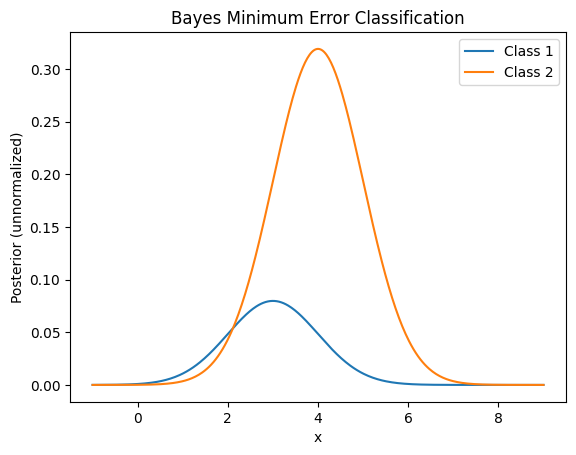

In [13]:
# Visualisasi Data
x_range = np.linspace(-1, 9, 400)

p1 = likelihood(x_range, mu1, sigma) * P_w1
p2 = likelihood(x_range, mu2, sigma) * P_w2

print(p1)
print(p2)

plt.figure()
plt.plot(x_range, p1, label='Class 1')
plt.plot(x_range, p2, label='Class 2')
plt.xlabel('x')
plt.ylabel('Posterior (unnormalized)')
plt.legend()
plt.title('Bayes Minimum Error Classification')
plt.show()

In [14]:
from dataclasses import dataclass
# Gabungkan data
data = np.concatenate([x1, x2])
true_label = np.array([1]*len(x1) + [2]*len(x2))
print(true_label)

pred_label = classify(data)
print(pred_label)

error_rate = np.mean(pred_label != true_label)
print(f'Error rate: {error_rate}')

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
[2 2 2 2 2 2 2 2 2 2 2 2 2 1 1 2 2 2 2 1 2 2 2 1 2 2 1 2 2 2 2 2 2 2 2 1 2
 1 1 2 2 2 2 2 1 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2
 1 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
Error rate: 0.435


b. mu1=2, sigma1=0,5,  mu2=4, sigma1=1, P_w1=0,5, P_w2=0,5

In [15]:
# Dua class (Asumsi menggunakan Gaussian)
np.random.seed(42)

# Membangkitkan data kelas 1
mu1, sigma = 2, 0.5
x1 = np.random.normal(mu1, sigma, 100)

# Membangkitkan data kelas 2
mu2, sigma = 4, 1.0
x2 = np.random.normal(mu2, sigma, 100)

# Posterior Probability
P_w1 = 0.5
P_w2 = 0.5

[2.21592421e-03 2.38820841e-03 2.57227117e-03 2.76878019e-03
 2.97843010e-03 3.20194266e-03 3.44006691e-03 3.69357936e-03
 3.96328390e-03 4.25001178e-03 4.55462148e-03 4.87799835e-03
 5.22105432e-03 5.58472738e-03 5.96998098e-03 6.37780331e-03
 6.80920640e-03 7.26522519e-03 7.74691631e-03 8.25535688e-03
 8.79164301e-03 9.35688821e-03 9.95222165e-03 1.05787863e-02
 1.12377366e-02 1.19302367e-02 1.26574574e-02 1.34205740e-02
 1.42207635e-02 1.50592013e-02 1.59370585e-02 1.68554984e-02
 1.78156731e-02 1.88187198e-02 1.98657570e-02 2.09578808e-02
 2.20961606e-02 2.32816348e-02 2.45153066e-02 2.57981398e-02
 2.71310535e-02 2.85149179e-02 2.99505498e-02 3.14387070e-02
 3.29800839e-02 3.45753066e-02 3.62249277e-02 3.79294215e-02
 3.96891788e-02 4.15045024e-02 4.33756019e-02 4.53025888e-02
 4.72854721e-02 4.93241537e-02 5.14184238e-02 5.35679566e-02
 5.57723064e-02 5.80309035e-02 6.03430509e-02 6.27079205e-02
 6.51245504e-02 6.75918418e-02 7.01085568e-02 7.26733160e-02
 7.52845971e-02 7.794073

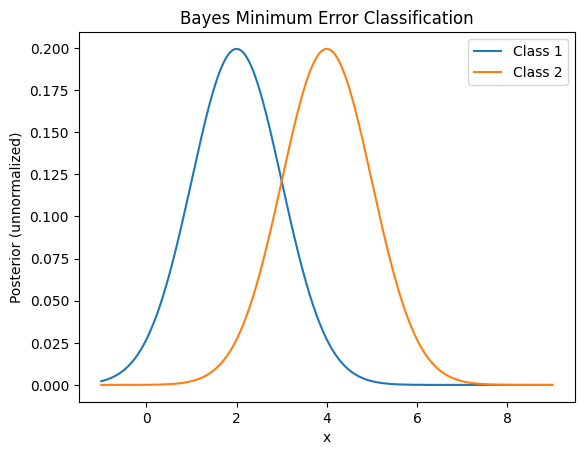

In [16]:
# Visualisasi Data
x_range = np.linspace(-1, 9, 400)

p1 = likelihood(x_range, mu1, sigma) * P_w1
p2 = likelihood(x_range, mu2, sigma) * P_w2

print(p1)
print(p2)

plt.figure()
plt.plot(x_range, p1, label='Class 1')
plt.plot(x_range, p2, label='Class 2')
plt.xlabel('x')
plt.ylabel('Posterior (unnormalized)')
plt.legend()
plt.title('Bayes Minimum Error Classification')
plt.show()

In [17]:
from dataclasses import dataclass
# Gabungkan data
data = np.concatenate([x1, x2])
true_label = np.array([1]*len(x1) + [2]*len(x2))
print(true_label)

pred_label = classify(data)
print(pred_label)

error_rate = np.mean(pred_label != true_label)
print(f'Error rate: {error_rate}')

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 1
 2 2 2 2 2 2 1 2 2 2 2 2 1 2 2 2 2 2 2 1 2 1 2 2 2 2 2 2 1 2 2 1 2 2 2 1 1
 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2
 2 2 2 2 1 2 2 2 1 2 2 2 2 2 1]
Error rate: 0.075


Hasil Perbandingan:
Dari nilai Error rate, diketahui bahwa model terbaik dihasilkan oleh kombinasi nilai mu1=2, sigma1=0,8, mu2=5, sigma1=1, P_w1=0,4, P_w2=0,6 dengan nilai error hanya sebesar 0,01.